# **P**anatopic **A**dversarial **N**uclei **C**lassification **a**nd **K**nowledge-**E**nhanced **S**egmentation using Pathopix-GANs
Dataset Structure
The dataset is organized into three folds: fold1, fold2, and fold3, consistent with the original dataset structure. Each fold contains data in a tabular format with the following four columns:

image: The RGB tile of the sample.
instances: A list of nuclei instances. Each instance represents exactly one nucleus and is in binary format (1 - nucleus, 0 - background)
categories: An integer class label for each nucleus, corresponding to one of the following categories:

1. Neoplastic
2. Inflammatory
3. Connective
4. Dead
5. Epithelial

tissue: The integer tissue type from which the sample originates, belonging to one of these categories:

1. Adrenal Gland
2. Bile Duct
3. Bladder
4. Breast
5. Cervix
6. Colon
7. Esophagus
8. Head & Neck
9. Kidney
10. Liver
11. Lung
12. Ovarian
13. Pancreatic
14. Prostate
15. Skin
16. Stomach
17. Testis
18. Thyroid
19. Uterus

### **Libraries**

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from random import choice
import random
from matplotlib.patches import Polygon
import torch
import json
import os
import numpy as np
import copy
import cv2
from tqdm import tqdm
from random import choice, randint


### **Augmentation (GAN) Pipeline**

In [47]:
def load_model(checkpoint_path, model, noise_scheduler):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint["model_state"])
    noise_scheduler.load_state_dict(checkpoint["noise_scheduler"])
    model.eval()
    return model, noise_scheduler

def process_noised_image(model, image_size=256):
    device = next(model.parameters()).device
    noised_image = torch.randn(1, 3, image_size, image_size).to(device)
    with torch.no_grad():
        output = model(noised_image)
    return output

def augment_dataset(coco_json, image_folder, model, noise_scheduler, class_id=4, num_augment=20):
    with open(coco_json, "r") as f:
        data = json.load(f)

    images = {img["id"]: img for img in data["images"]}
    annotations = data["annotations"]

    dead_cell_anns = [ann for ann in annotations if ann["category_id"] == class_id]
    dead_cell_images = set(ann["image_id"] for ann in dead_cell_anns)

    new_images = []
    new_annotations = []
    image_id_offset = max(images.keys()) + 1
    annotation_id_offset = max(ann["id"] for ann in annotations) + 1

    model, noise_scheduler = load_model("model_checkpoint.pth", model, noise_scheduler)

    for img_id in tqdm(dead_cell_images, desc="Augmenting Images"):
        img_data = images[img_id]
        img_path = os.path.join(image_folder, img_data["file_name"])
        img = cv2.imread(img_path)

        if img is None:
            continue

        img_h, img_w = img.shape[:2]
        img_annotations = [ann for ann in dead_cell_anns if ann["image_id"] == img_id]

        for _ in range(num_augment):
            noised_output = process_noised_image(model, image_size=256)
            aug_img_id = image_id_offset + len(new_images)
            aug_ann_id = annotation_id_offset + len(new_annotations)

            aug_img_name = f"aug_{aug_img_id}.jpg"
            aug_img_path = os.path.join(image_folder, aug_img_name)
            cv2.imwrite(aug_img_path, np.array(noised_output.cpu().squeeze().permute(1, 2, 0) * 255, dtype=np.uint8))

            new_images.append({
                "id": aug_img_id,
                "file_name": aug_img_name,
                "width": img_w,
                "height": img_h
            })

            for ann in img_annotations:
                new_ann = ann.copy()
                new_ann["id"] = aug_ann_id
                new_ann["image_id"] = aug_img_id
                new_annotations.append(new_ann)
                aug_ann_id += 1

    data["images"].extend(new_images)
    data["annotations"].extend(new_annotations)

    with open(coco_json, "w") as f:
        json.dump(data, f, indent=4)

### **Inference**

In [46]:
#!rm -r train
#!rm -r train.json
#!cp -r test/* .

In [ ]:
augment_dataset("train.json", "train", "train.json", class_id=4, num_augment=20, restrict_class = [1])
augment_dataset("train.json", "train", "train.json", class_id=5, num_augment=1, restrict_class = [1, 3])

Augmenting Images: 100%|██████████| 61/61 [00:05<00:00, 11.20it/s]


Augmented dataset saved to train.json


Augmenting Images: 100%|██████████| 447/447 [00:04<00:00, 93.31it/s] 


Augmented dataset saved to train.json


### **Updated Distribution**

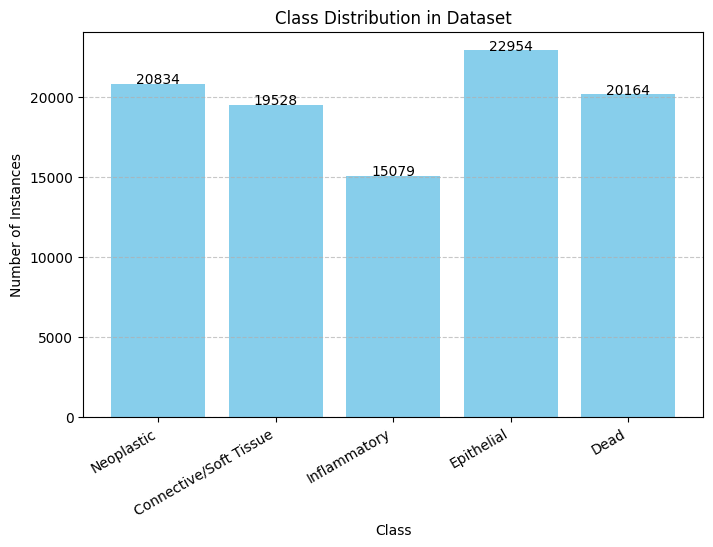

In [39]:
CLASS_LABELS = {
    1: "Neoplastic",
    2: "Inflammatory",
    3: "Connective/Soft Tissue",
    4: "Dead",
    5: "Epithelial"
}

def load_coco_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    return data

def get_class_distribution(coco_data):
    class_count = Counter()

    for ann in coco_data["annotations"]:
        class_count[ann["category_id"]] += 1

    return dict(class_count)

def plot_class_distribution(class_dist, title="Class Distribution in Dataset"):
    class_ids = list(class_dist.keys())
    counts = list(class_dist.values())

    labels = [CLASS_LABELS.get(cid, f"Class {cid}") for cid in class_ids]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, counts, color="skyblue")
    plt.xlabel("Class")
    plt.ylabel("Number of Instances")
    plt.title(title)
    plt.xticks(rotation=30, ha="right")  
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    for i, v in enumerate(counts):
        plt.text(i, v + 2, str(v), ha="center", fontsize=10)

    plt.show()

coco_json_path = "train.json"  
coco_data = load_coco_json(coco_json_path)
class_distribution = get_class_distribution(coco_data)

plot_class_distribution(class_distribution)

### **Predicted Images**

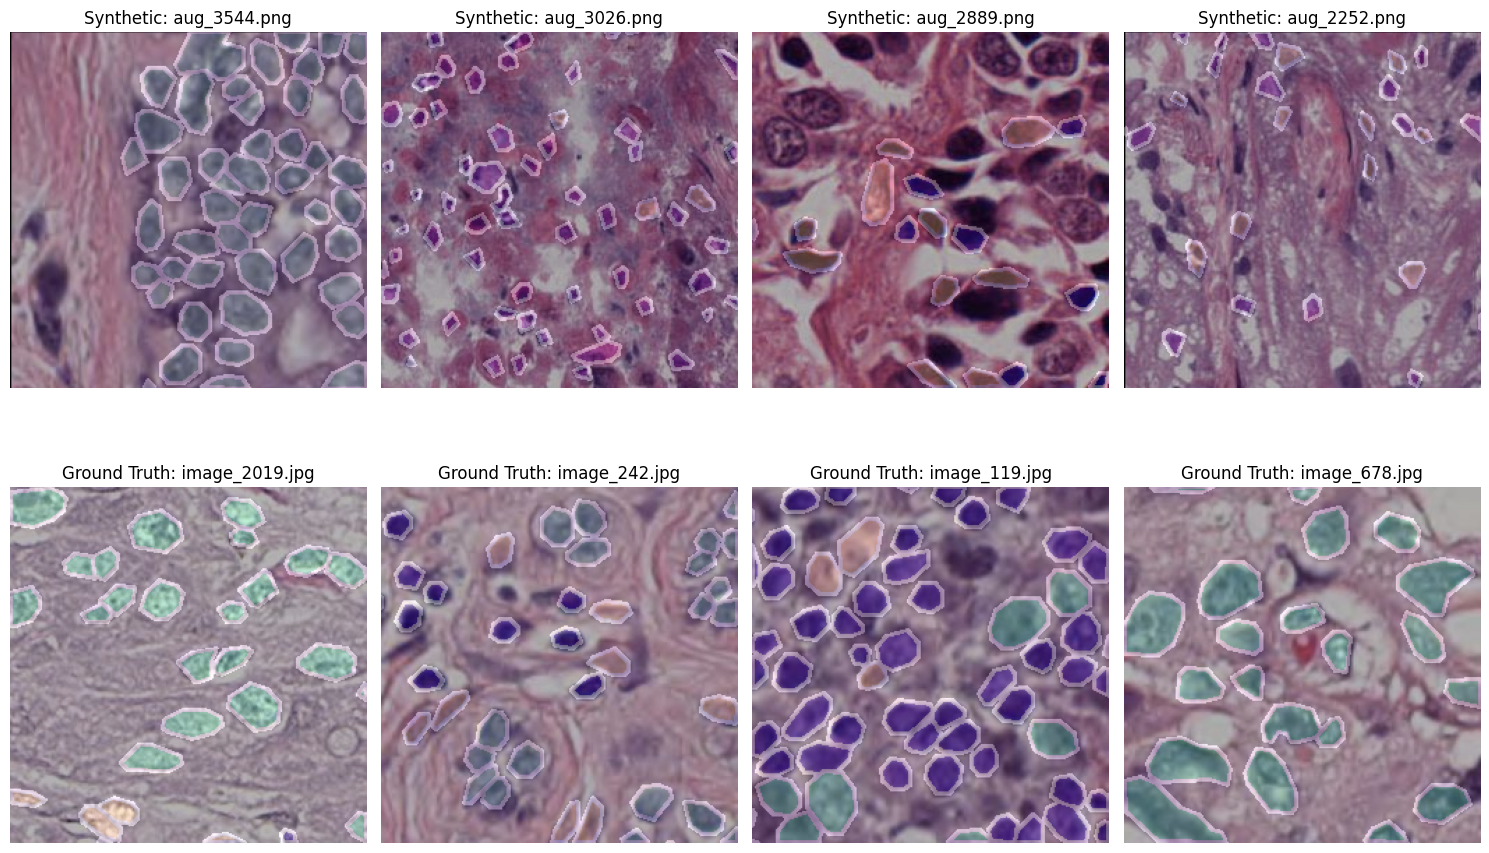

In [ ]:
def load_coco_json(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)
    return data

def generate_color_map(categories):
    color_map = {}
    for category in categories:
        color_map[category['id']] = (randint(0, 255), randint(0, 255), randint(0, 255))
    return color_map

def overlay_segmentation(image, annotations, image_width, image_height, color_map, outline_thickness=2):
    mask = np.zeros((image_height, image_width, 3), dtype=np.uint8)

    for ann in annotations:
        if 'segmentation' in ann:
            category_id = ann['category_id']
            color = color_map.get(category_id, (0, 0, 255))  
            for segment in ann["segmentation"]:
                polygon = np.array(segment).reshape(-1, 2).astype(int)
                cv2.fillPoly(mask, [polygon], color)
                cv2.polylines(mask, [polygon], isClosed=True, color=(256, 256, 256), thickness=outline_thickness)

    image_with_mask = cv2.addWeighted(image, 0.7, mask, 0.3, 0)
    return image_with_mask, mask

def display_augmented_and_ground_truth_images(coco_json_path, image_folder, num_images=4):
    coco_data = load_coco_json(coco_json_path)

    color_map = generate_color_map(coco_data['categories'])

    augmented_images = [img for img in coco_data["images"] if "aug_" in img["file_name"]]
    ground_truth_images = [img for img in coco_data["images"] if "image_" in img["file_name"]]

    fig, axes = plt.subplots(2, num_images, figsize=(15, 10))

    for i in range(num_images):
        gt_img_data = choice(ground_truth_images)
        img_path = f"{image_folder}/{gt_img_data['file_name']}"
        img = cv2.imread(img_path)

        if img is None:
            continue

        img_h, img_w = img.shape[:2]
        img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == gt_img_data["id"]]

        img_with_mask, _ = overlay_segmentation(img, img_annotations, img_w, img_h, color_map)

        axes[1, i].imshow(cv2.cvtColor(img_with_mask, cv2.COLOR_BGR2RGB))
        axes[1, i].set_title(f"Ground Truth: {gt_img_data['file_name']}")
        axes[1, i].axis('off')

    for i in range(num_images):
        aug_img_data = choice(augmented_images)
        img_path = f"{image_folder}/{aug_img_data['file_name']}"
        img = cv2.imread(img_path)

        if img is None:
            continue

        img_h, img_w = img.shape[:2]
        img_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == aug_img_data["id"]]

        img_with_mask, _ = overlay_segmentation(img, img_annotations, img_w, img_h, color_map)

        axes[0, i].imshow(cv2.cvtColor(img_with_mask, cv2.COLOR_BGR2RGB))
        axes[0, i].set_title(f"Synthetic: {aug_img_data['file_name']}")
        axes[0, i].axis('off')

    plt.tight_layout()
    plt.show()

coco_json_path = "train.json"
image_folder = "train"
display_augmented_and_ground_truth_images(coco_json_path, image_folder)